In [1]:
import sys
sys.path.append('../code')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from memorycontext_cuesoma_contextsoma import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

/users/ntolley/.conda/envs/jaxley/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path =  '/users/ntolley/data/ntolley/dendractor/random_initialization_memorycontext'
file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

100%|██████████| 7/7 [00:28<00:00,  4.02s/it]


In [3]:
print(list(random_init_dict.keys()))

['cuedend_contextdend_celldend', 'cuedend_contextdend', 'cuedend_contextsoma', 'cuesoma_contextdend', 'cuesoma_contextsoma_celldend', 'cuesoma_contextsoma_cellsoma', 'cuesoma_contextsoma']


In [211]:
# res_dict = random_init_dict['cuesoma_contextsoma']
# res_dict = random_init_dict['cuesoma_contextdend']
# res_dict = random_init_dict['cuedend_contextsoma']
# res_dict = random_init_dict['cuedend_contextdend']

res_dict = random_init_dict['cuesoma_contextsoma_cellsoma']

name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

cuesoma_contextsoma_cellsoma


In [212]:
t_max = 2000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [213]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)


num_model_sims = 15

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_model_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_model_sims)])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])


    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list)

[1.4279004001375737, 1.4279004020147352, 1.4279004007185456, 1.4279003996250013, 1.427900401692092, 1.427900399968922, 1.4279004011358, 1.4279004007230411, 1.4279004009745802, 1.4279004009038998, 1.4279004008970018, 1.427900401621011, 1.4279004012678813, 1.4279004010363243, 1.427900400960407, 1.4279003999945574, 1.427900401201819, 1.4279004011292404, 1.4279004006018259, 1.427900399601828]


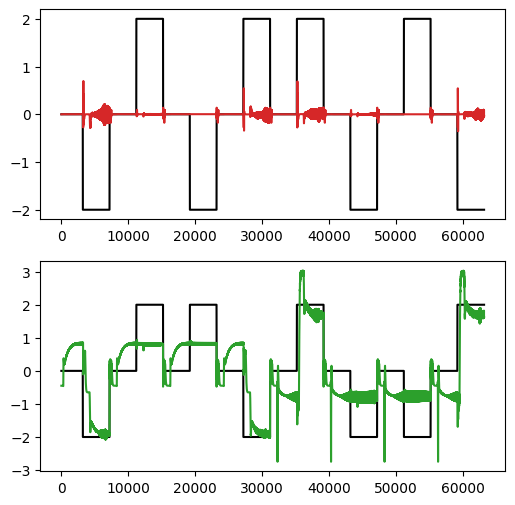

In [214]:
stop_idx = None
# stop_idx = 10_000

plt.figure(figsize=(6,6))
plt.subplot(2,1,1)
plt.plot(targets[burn_in:stop_idx,0], color='k')
plt.plot(y_pred[:stop_idx,0], color='C3')

plt.subplot(2,1,2)
plt.plot(targets[burn_in:stop_idx,1], color='k')
plt.plot(y_pred[:stop_idx,1], color='C2')

In [215]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

In [216]:
gid_ranges

{'E': range(0, 100),
 'I': range(100, 150),
 'context': range(150, 200),
 'cue': range(200, 250),
 'E_rate': range(250, 350),
 'I_rate': range(350, 400)}

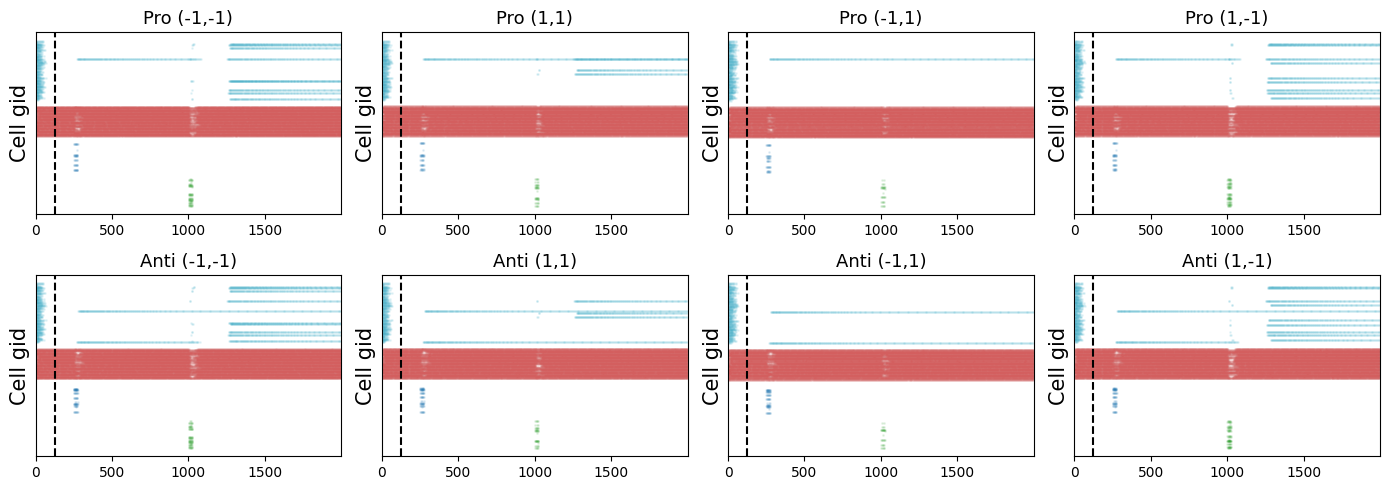

In [217]:
fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    plt.xlim(0, time_vec[-1])
    plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()

In [218]:
pca = PCA()
pca.fit(np.concatenate(x_train))

PCA()

In [219]:
def make_trajectory_figure(start_idx, end_idx, ax, dim1=0, dim2=1, dim3=2,
                           color1='C0', color2='C9', color3='C1', color4='C3',
                           label1=None, label2=None, label3=None, label4=None):
    # ax = plt.figure(figsize=(7,7)).add_subplot(111,projection='3d')
    ax.grid(False)
    ax.set_xlabel(f'PC{dim1+1}', fontsize=labelsize)
    ax.set_ylabel(f'PC{dim2+1}', fontsize=labelsize)
    ax.set_zlabel(f'PC{dim3+1}', fontsize=labelsize)

    ax.plot(points1[start_idx:end_idx,dim1], points1[start_idx:end_idx, dim2], points1[start_idx:end_idx, dim3], color=color1, label=label1)
    ax.plot(points2[start_idx:end_idx,dim1], points2[start_idx:end_idx, dim2], points2[start_idx:end_idx, dim3], color=color2, label=label2)
    ax.plot(points3[start_idx:end_idx,dim1], points3[start_idx:end_idx, dim2], points3[start_idx:end_idx, dim3], color=color3, label=label3)
    ax.plot(points4[start_idx:end_idx,dim1], points4[start_idx:end_idx, dim2], points4[start_idx:end_idx, dim3], color=color4, label=label4)


    ax.scatter(points1[start_idx,dim1], points1[start_idx, dim2], points1[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points2[start_idx,dim1], points2[start_idx, dim2], points2[start_idx, dim3], color='k', marker='*', s=50)

    ax.scatter(points1[cue_idx,dim1], points1[cue_idx, dim2], points1[cue_idx, dim3], color='k')
    ax.scatter(points2[cue_idx,dim1], points2[cue_idx, dim2], points2[cue_idx, dim3], color='k')

    ax.scatter(points1[end_idx,dim1], points1[end_idx, dim2], points1[end_idx, dim3], color=color1, s=100, edgecolor='k')
    ax.scatter(points2[end_idx,dim1], points2[end_idx, dim2], points2[end_idx, dim3], color=color2, s=100, edgecolor='k')
    ax.scatter(points3[end_idx,dim1], points3[end_idx, dim2], points3[end_idx, dim3], color=color3, s=100, edgecolor='k')
    ax.scatter(points4[end_idx,dim1], points4[end_idx, dim2], points4[end_idx, dim3], color=color4, s=100, edgecolor='k')


    ax.view_init(elev=30., azim=-200, roll=0)

    # plt.tight_layout()
    # plt.show()

In [232]:
ticksize = 11
labelsize = 15

sim_idx1, sim_idx2 = 0,4
sim_idx3, sim_idx4 = 1,5

# sim_idx1, sim_idx2 = 0,4
# sim_idx3, sim_idx4 = 1,5

# sim_idx1, sim_idx2 = 2,6
# sim_idx3, sim_idx4 = 3,7

cue_idx = 4000

points1 = pca.transform(output_array[sim_idx1, gid_ranges['E_rate'], :].T)
points2 = pca.transform(output_array[sim_idx2, gid_ranges['E_rate'], :].T)
points3 = pca.transform(output_array[sim_idx3, gid_ranges['E_rate'], :].T)
points4 = pca.transform(output_array[sim_idx4, gid_ranges['E_rate'], :].T)



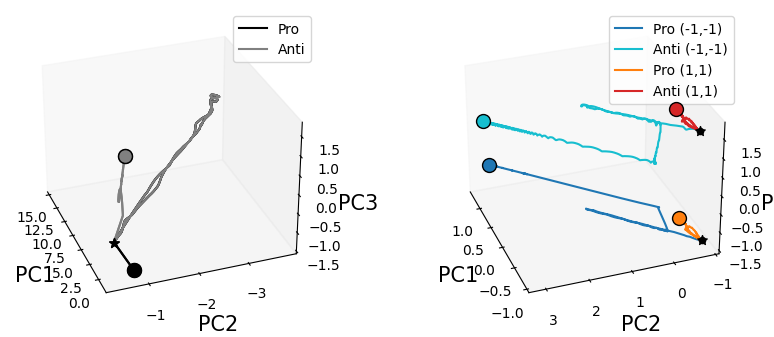

In [233]:
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

make_trajectory_figure(0, cue_idx, ax1, 0, 1, 2, color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(cue_idx, cue_idx+2000, ax2, 0, 1, 2, label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

# limits = [(-9, 5), (-5, 6), (-5, 3.4)]
# limits = [(-9, 5), (-5, 6), (-5, 3.4)]
# for ax_plot in [ax1, ax2]:
#     ax_plot.set_xlim(limits[0])
#     ax_plot.set_ylim(limits[1])
#     ax_plot.set_zlim(limits[2])

ax1.legend()
ax2.legend()
# plt.savefig('context_trajectory.svg')


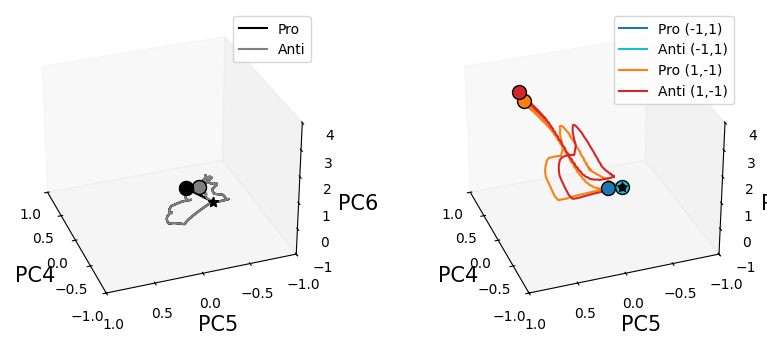

In [230]:
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

make_trajectory_figure(0, cue_idx, ax1, 3, 4, 5, color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(cue_idx, cue_idx+2000, ax2, 3, 4, 5, label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

# limits = [(-2,3), (-3,4.5), (-2, 5)]
limits = [(-1,1), (-1,1), (-1, 4)]
for ax_plot in [ax1, ax2]:
    ax_plot.set_xlim(limits[0])
    ax_plot.set_ylim(limits[1])
    ax_plot.set_zlim(limits[2])

ax1.legend()
ax2.legend()